# Clustering Tuning Explorer

Esplorazione interattiva di sweep di tuning **già eseguite** — non rifà né sostituisce la sweep, legge solo `tuning_results.csv` + le diagnostiche standalone già
scritte su disco. Nessuna selezione automatica di `k`/iperparametri qui (`code_standards.md` §0) è uno strumento di lettura.

Diverso da `clustering_evaluation.ipynb` (che confronta run **prodotte**):
questo lavora sulla fase *precedente*, la scelta di `k` dentro una sweep di tuning — vedi
`knowledge/dim_reduction_clustering/clustering_tuning_guide.md` per come leggere ogni indice.



In [22]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Repo root isn't on sys.path when this notebook runs with cwd=notebooks/post-results_analysis/ -
# same fix as clustering_evaluation.ipynb / temp/*/run_prototype.py.
NOTEBOOK_REPO_ROOT = Path.cwd().resolve().parents[1]
if str(NOTEBOOK_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_REPO_ROOT))

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)

In [23]:

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from src.analysis.consensus_clustering import subsampling_stability_index
from src.utils.artifacts import load_matrix


def show_images(run_dir: Path, image_names: list[str]) -> None:
    """Displays one or more diagnostic images from the same run side by side (e.g. one
    dendrogram per linkage, or a single interclass_distance_matrix.png). Raises if any
    is missing rather than skipping it."""
    fig, axes = plt.subplots(1, len(image_names), figsize=(7 * len(image_names), 7))
    axes = [axes] if len(image_names) == 1 else axes
    for ax, image_name in zip(axes, image_names):
        image_path = run_dir / image_name
        if not image_path.is_file():
            raise FileNotFoundError(f"{image_name!r} not found in {run_dir}")
        ax.imshow(plt.imread(image_path))
        ax.set_title(image_name, fontsize=10)
        ax.axis("off")
    fig.tight_layout()
    plt.show()


def load_tuning_results(run_dirs: list[Path]) -> pd.DataFrame:
    """Reads tuning_results.csv from each run dir and concatenates them, tagged by a
    `run` column (the run dir's own name, e.g. "27-08_s1.1_euclidean_n10")."""
    frames = []
    for run_dir in run_dirs:
        csv_path = run_dir / "tuning_results.csv"
        if not csv_path.is_file():
            raise FileNotFoundError(f"no tuning_results.csv in {run_dir}")
        df = pd.read_csv(csv_path)
        df.insert(0, "run", run_dir.name)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def list_combo_keys(run_dir: Path) -> list[str]:
    """Lists every combination key saved in a run's clusterings.npz (save_tuning_clusterings:
    true), e.g. "n_clusters=2,linkage=average,metric=cosine" - use to find the exact key for
    crosstab_run below."""
    npz_path = run_dir / "clusterings.npz"
    if not npz_path.is_file():
        raise FileNotFoundError(f"no clusterings.npz in {run_dir} - rerun tuning with save_tuning_clusterings=true")
    return sorted(np.load(npz_path).keys())


def crosstab_run(run_dir: Path, combo_key: str, metadata_column: str) -> pd.DataFrame:
    """Cross-tabulates one tuning combination's cluster labels against a metadata column,
    to check whether a candidate n_clusters is tracking a known confound (e.g. lesion_side)
    instead of genuine structure. `combo_key` must match a key in clusterings.npz exactly -
    see list_combo_keys(run_dir)."""
    npz_path = run_dir / "clusterings.npz"
    if not npz_path.is_file():
        raise FileNotFoundError(f"no clusterings.npz in {run_dir} - rerun tuning with save_tuning_clusterings=true")
    metadata_path = run_dir / "metadata.csv"
    if not metadata_path.is_file():
        raise FileNotFoundError(f"no metadata.csv in {run_dir}")

    z = np.load(npz_path)
    if combo_key not in z:
        raise KeyError(f"{combo_key!r} not in {npz_path} - available keys: {sorted(z.keys())}")
    labels = z[combo_key]

    metadata = pd.read_csv(metadata_path)
    if metadata_column not in metadata.columns:
        raise KeyError(f"{metadata_column!r} not a column in {metadata_path} - available: {list(metadata.columns)}")

    return pd.crosstab(labels, metadata[metadata_column])

def compare_combos(run_dir: Path, combo_key_a: str, combo_key_b: str) -> dict[str, float]:
    """ARI + NMI between two combinations' cluster labels from the same run's
    clusterings.npz - quantifies "how similar are these two candidates" instead of eyeballing
    two crosstabs side by side (e.g. does average/ward really converge on the same partition,
    or just look similar?). Raises if either key is missing."""
    npz_path = run_dir / "clusterings.npz"
    if not npz_path.is_file():
        raise FileNotFoundError(f"no clusterings.npz in {run_dir} - rerun tuning with save_tuning_clusterings=true")
    z = np.load(npz_path)
    for key in (combo_key_a, combo_key_b):
        if key not in z:
            raise KeyError(f"{key!r} not in {npz_path} - available keys: {sorted(z.keys())}")
    labels_a, labels_b = z[combo_key_a], z[combo_key_b]
    return {
        "ari": adjusted_rand_score(labels_a, labels_b),
        "nmi": normalized_mutual_info_score(labels_a, labels_b),
    }


def _read_tuning_config(run_dir: Path) -> dict:
    """Parses the JSON config block embedded in a tuning run's config.md (a fenced ```json
    block) - a different format from production's "Params used:" line
    (src.utils.artifacts.read_run_params), so not directly reusable here."""
    config_path = run_dir / "config.md"
    if not config_path.is_file():
        raise FileNotFoundError(f"no config.md in {run_dir}")
    text = config_path.read_text()
    if "```json" not in text:
        raise ValueError(f"{config_path} has no ```json config block")
    block = text.split("```json", 1)[1].split("```", 1)[0]
    return json.loads(block)


def _parse_combo_key(combo_key: str) -> dict:
    """Converts a clusterings.npz key like "n_clusters=5,linkage=average,metric=euclidean"
    into a params dict for CLUSTERING_METHODS, casting each value to int/float when possible,
    else leaving it as a string."""
    params = {}
    for part in combo_key.split(","):
        name, value = part.split("=")
        try:
            params[name] = int(value)
        except ValueError:
            try:
                params[name] = float(value)
            except ValueError:
                params[name] = value
    return params


def stability_check(run_dir: Path, combo_key: str, subsample_fraction: float = 0.8) -> float:
    """Subsampling Stability Index (see clustering_evaluation.ipynb §5) for one tuning
    combination - refits the same method/params on an 80% subsample of the same embedding
    this run swept over (its own config.md `input_path`, loaded via load_matrix - the same
    contract clustering.py/embedding_app.py use) and scores ARI against a full-sample fit.
    Doesn't require a production run to exist first - works directly on a tuning combo.
    A value near 1 means the clustering doesn't depend on which subjects happened to be
    sampled; a low value is a reason to look closer, not to discard the candidate outright."""
    config = _read_tuning_config(run_dir)
    input_path = NOTEBOOK_REPO_ROOT / config["input_path"]

    X, embedding_metadata, _extra_arrays = load_matrix(input_path)
    tuning_metadata = pd.read_csv(run_dir / "metadata.csv")
    if not embedding_metadata["subject_id"].equals(tuning_metadata["subject_id"]):
        raise ValueError(
            f"{input_path}'s subject_id order doesn't match {run_dir}/metadata.csv - "
            "can't reuse X positionally for this run"
        )

    return subsampling_stability_index(config["clustering_method"], X, _parse_combo_key(combo_key), subsample_fraction)


## Agglomerative

### 0. Scegli l'embedding da analizzare

Un solo `RUN_DIR` alla volta per le sezioni 1-6 (metric → linkage → n_clusters → artefatto →
confronto tra combinazioni → stabilità) - il confronto tra più embedding è in fondo, sezione 7.

Esempio: `27-08_s1.1_euclidean_n3` - non ancora controllata nelle sessioni precedenti
(`n2`/`n10` euclidean e tutti e 3 i `dice` erano già stati fatti).

In [24]:
RUN_DIR = NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/agglomerative/27-08_s1.1_euclidean_n3"

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"run directory not found: {RUN_DIR}")

results = pd.read_csv(RUN_DIR / "tuning_results.csv")
print(f"{len(results)} righe, metric sweepate: {sorted(results['metric'].unique())}, linkage sweepate: {sorted(results['linkage'].unique())}")

70 righe, metric sweepate: ['cosine', 'euclidean', 'manhattan'], linkage sweepate: ['average', 'complete', 'single', 'ward']


## 1. Quale `metric` guardare per prima? (interclass distance matrix)

Pre-check indipendente dal fit vero e proprio: usa `dataset` come proxy debole di ground truth
e mostra, per ciascuna `metric` sweepata, quanto sono compatti i gruppi noti sulla diagonale
vs. quanto sono separati fuori diagonale. Una `metric` "migliore" per questo spazio tiene la
diagonale bassa e le celle fuori diagonale alte. Non dice nulla su `n_clusters`.

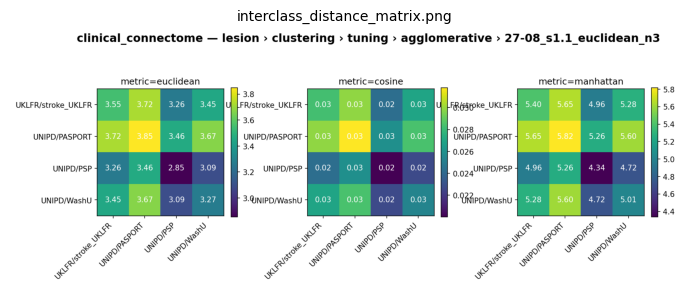

In [25]:
show_images(RUN_DIR, ["interclass_distance_matrix.png"])

### 2. `linkage`, dato un `metric` (dendrogrammi)

**Attenzione**: i dendrogrammi sono generati con `metric` **fissato a `euclidean`**
(`base_params` di `params_clustering.json`, non la `metric` sweepata) — vedi
`src/pipeline/clustering.py::_write_agglomerative_diagnostics`. Sono quindi una diagnostica
valida solo per giudicare `linkage` **dentro la geometria euclidea**, non per `cosine`/`manhattan`
— per quelle due l'unico segnale resta la tabella `tuning_results.csv` (sezione 3).

`single` linkage va quasi sempre scartato (chaining effect) — guardalo comunque, non darlo per
scontato a priori.

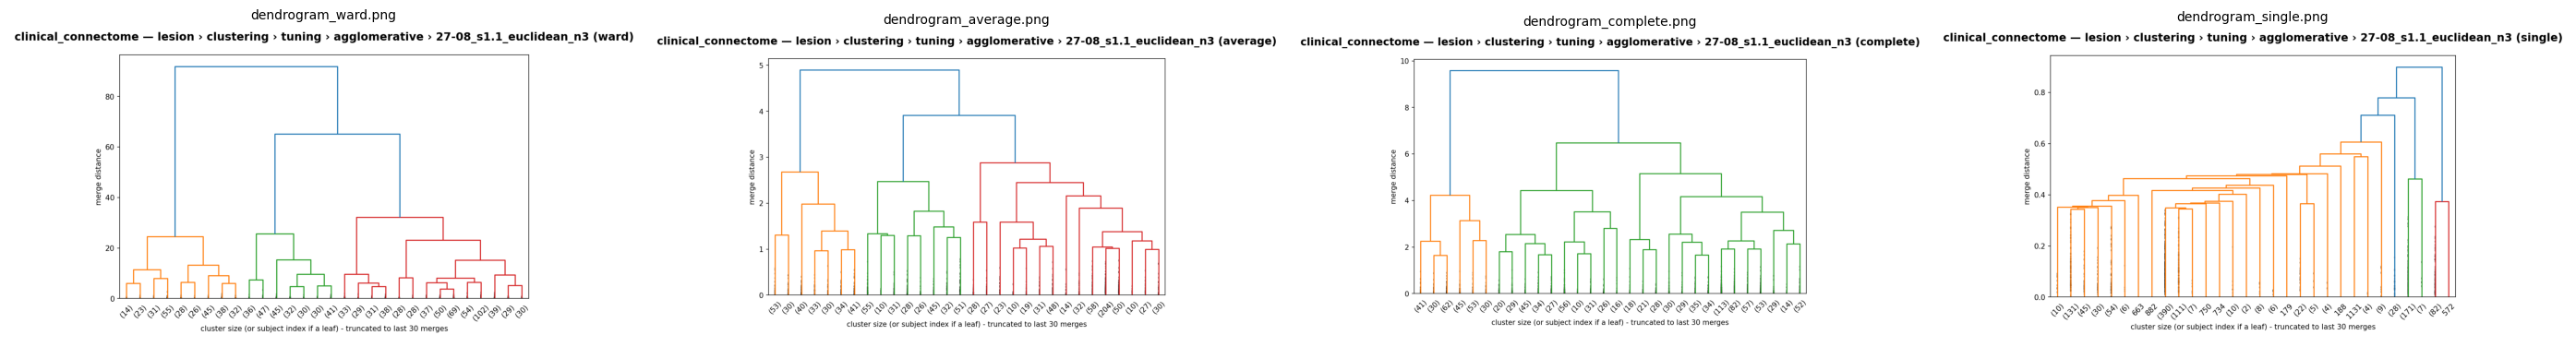

In [26]:
LINKAGES = ["ward", "average", "complete", "single"]
show_images(RUN_DIR, [f"dendrogram_{linkage}.png" for linkage in LINKAGES])

### 3. `n_clusters`, dentro il `metric` scelto

Filtra `results` sulla `metric` di cui ti fidi (dalla sezione 1) e guarda l'andamento di
Silhouette/CH/DB al variare di `n_clusters` (CH/DB restano `NaN` per `metric != "euclidean"`,
non è un bug - vedi `clustering_tuning_guide.md`). `single` linkage è escluso di default qui,
non perché "va sempre scartato in automatico" ma perché la sezione 2 lo valuta a parte.

In [27]:
METRIC = "euclidean"

(
    results[(results["metric"] == METRIC) & (results["linkage"] != "single")]
    .sort_values(["linkage", "n_clusters"])
)

,n_clusters,linkage,metric,silhouette,noise_fraction,calinski_harabasz,davies_bouldin
1,2,average,euclidean,0.451849,0.0,957.999591,0.764335
11,3,average,euclidean,0.481164,0.0,1443.829287,0.778949
21,4,average,euclidean,0.443743,0.0,1164.372858,0.764730
31,5,average,euclidean,0.434641,0.0,1079.318691,0.737092
41,6,average,euclidean,0.423775,0.0,1078.688298,0.759393
51,8,average,euclidean,0.445557,0.0,1255.366407,0.732231
61,10,average,euclidean,0.432104,0.0,1253.265280,0.676712
4,2,complete,euclidean,0.451849,0.0,957.999591,0.764335
14,3,complete,euclidean,0.480582,0.0,1458.285122,0.785972
24,4,complete,euclidean,0.429988,0.0,1185.718365,0.802358


### 4. Check artefatto: crosstab del `k` candidato contro i metadati

Prima di considerare un `k` un candidato vero, verifica che non stia solo ritrovando
un'informazione già nei metadati (visto ripetutamente per `lesion_side` su k=2 negli embedding
`dice`). Esempio qui: `metric="cosine", n_clusters=2` aveva silhouette=0.730 nella tabella
aggregata multi-embedding (sezione 7) — mai controllata per questa run, la verifichiamo ora.

In [28]:
list_combo_keys(RUN_DIR)[:10]  # per trovare il COMBO_KEY esatto sotto

['n_clusters=10,linkage=average,metric=cosine',
 'n_clusters=10,linkage=average,metric=euclidean',
 'n_clusters=10,linkage=average,metric=manhattan',
 'n_clusters=10,linkage=complete,metric=cosine',
 'n_clusters=10,linkage=complete,metric=euclidean',
 'n_clusters=10,linkage=complete,metric=manhattan',
 'n_clusters=10,linkage=single,metric=cosine',
 'n_clusters=10,linkage=single,metric=euclidean',
 'n_clusters=10,linkage=single,metric=manhattan',
 'n_clusters=10,linkage=ward,metric=euclidean']

In [29]:
COMBO_KEY = "n_clusters=2,linkage=complete,metric=cosine"
METADATA_COLUMN = "lesion_side"

crosstab_run(RUN_DIR, COMBO_KEY, METADATA_COLUMN)

lesion_side,left,right,unknown
row_0,,,
0,397,409,166
1,148,0,30


### 5. Confronto quantitativo tra combinazioni (ARI/NMI)

Finora un'affermazione tipo "`average` e `ward` convergono quasi sulla stessa partizione" l'abbiamo
verificata solo a occhio confrontando due crosstab. Qui si quantifica con ARI/NMI
(`sklearn.metrics`, stesso calcolo di `clustering_evaluation.ipynb` §3, applicato però a due
combinazioni della **stessa** sweep invece che a due run prodotte) - utile sia per confrontare
`linkage` diversi allo stesso `k`, sia due `k` vicini tra loro quando la scelta è incerta.

ARI/NMI vanno da 0 (nessun accordo oltre il caso) a 1 (partizioni identiche).

In [30]:
COMBO_KEY_A = "n_clusters=5,linkage=average,metric=euclidean"
COMBO_KEY_B = "n_clusters=5,linkage=ward,metric=euclidean"

compare_combos(RUN_DIR, COMBO_KEY_A, COMBO_KEY_B)

{'ari': 0.682123488224098, 'nmi': 0.8138802407397145}

### 6. Subsampling Stability Index

Rifitta lo stesso metodo/parametri di un candidato su un campione all'80% dei soggetti (senza
reinserimento) e calcola l'ARI col fit sul 100% - un valore vicino a 1 indica che il clustering
non dipende da un piccolo sottoinsieme di soggetti (es. outlier), un valore basso è un segnale da
approfondire, non un motivo per scartare il candidato in automatico (`clustering_evaluation.ipynb`
§5, stessa funzione - qui applicata direttamente a un candidato di tuning, senza dover prima
produrre una run). L'embedding (`X`) viene ricaricato dal `input_path` registrato nel `config.md`
della sweep, non serve `matrix.npy` (che il tuning non salva).

In [31]:
COMBO_KEY = "n_clusters=5,linkage=ward,metric=euclidean"

stability_check(RUN_DIR, COMBO_KEY, subsample_fraction=0.8)

0.9595809292930771

### 7. Vista globale multi-embedding

Solo dopo aver fatto 1-4 su ogni embedding separatamente: confronta i `tuning_results.csv` e/o
una stessa diagnostica fianco a fianco su più `RUN_DIRS` - utile per vedere se un `k` sopravvissuto
al check si ripete su più dimensionalità/metric UMAP a monte. Non è un confronto numerico diretto
tra embedding (spazi diversi) - solo qualitativo.

In [32]:
RUN_DIRS = [
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/agglomerative/27-08_s1.1_euclidean_n2",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/agglomerative/27-08_s1.1_euclidean_n3",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/agglomerative/27-08_s1.1_euclidean_n10",
]
for run_dir in RUN_DIRS:
    if not run_dir.is_dir():
        raise FileNotFoundError(f"run directory not found: {run_dir}")

all_results = load_tuning_results(RUN_DIRS)
print(f"{len(all_results)} righe, run: {sorted(all_results['run'].unique())}")
all_results[all_results["linkage"] != "single"].sort_values("silhouette", ascending=False).groupby(["run", "metric"]).head(1)

210 righe, run: ['27-08_s1.1_euclidean_n10', '27-08_s1.1_euclidean_n2', '27-08_s1.1_euclidean_n3']


,run,n_clusters,linkage,metric,silhouette,noise_fraction,calinski_harabasz,davies_bouldin
12,27-08_s1.1_euclidean_n2,3,average,cosine,0.750781,0.0,NaN,NaN
75,27-08_s1.1_euclidean_n3,2,complete,cosine,0.730168,0.0,NaN,NaN
162,27-08_s1.1_euclidean_n10,4,average,cosine,0.665396,0.0,NaN,NaN
31,27-08_s1.1_euclidean_n2,5,average,euclidean,0.496595,0.0,1384.734553,0.618362
43,27-08_s1.1_euclidean_n2,6,average,manhattan,0.491239,0.0,NaN,NaN
83,27-08_s1.1_euclidean_n3,3,average,manhattan,0.487295,0.0,NaN,NaN
80,27-08_s1.1_euclidean_n3,3,ward,euclidean,0.481611,0.0,1460.136715,0.784455
164,27-08_s1.1_euclidean_n10,4,complete,euclidean,0.445590,0.0,1006.928463,0.787231
163,27-08_s1.1_euclidean_n10,4,average,manhattan,0.440317,0.0,NaN,NaN


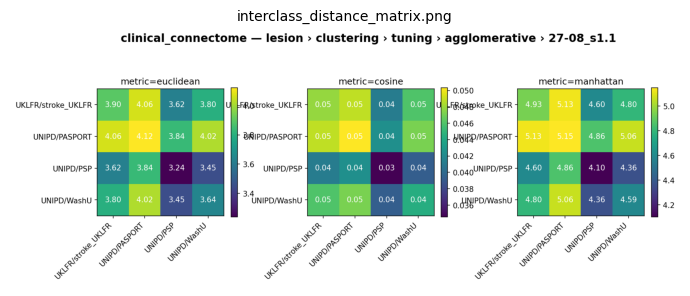

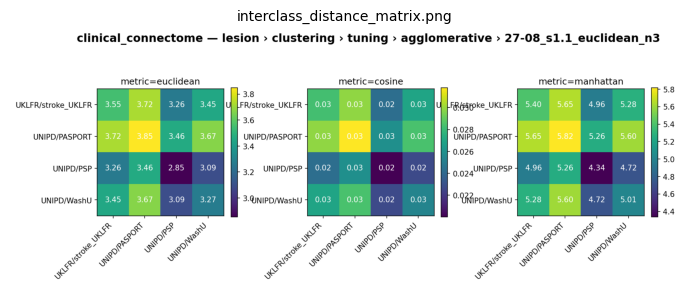

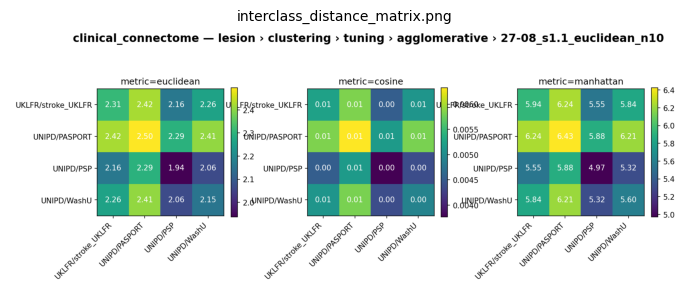

In [33]:
IMAGE_NAME = "interclass_distance_matrix.png"
for run_dir in RUN_DIRS:
    show_images(run_dir, [IMAGE_NAME])